          CONFIDENCE INTERVAL ESTIMATION REPORT (95%)
Number of Replications (n) : 10
------------------------------------------------------------
Replication  1 Average Waiting Time : 4.7980 min
Replication  2 Average Waiting Time : 4.4170 min
Replication  3 Average Waiting Time : 4.8886 min
Replication  4 Average Waiting Time : 5.4138 min
Replication  5 Average Waiting Time : 4.3595 min
Replication  6 Average Waiting Time : 4.3595 min
Replication  7 Average Waiting Time : 5.4475 min
Replication  8 Average Waiting Time : 4.9605 min
Replication  9 Average Waiting Time : 4.2183 min
Replication 10 Average Waiting Time : 4.8255 min
------------------------------------------------------------
Sample Mean (Y-bar)        : 4.7688 min
Margin of Error (Half-Width): 0.3103 min
95% Confidence Interval    : [4.4585 to 5.0792] min


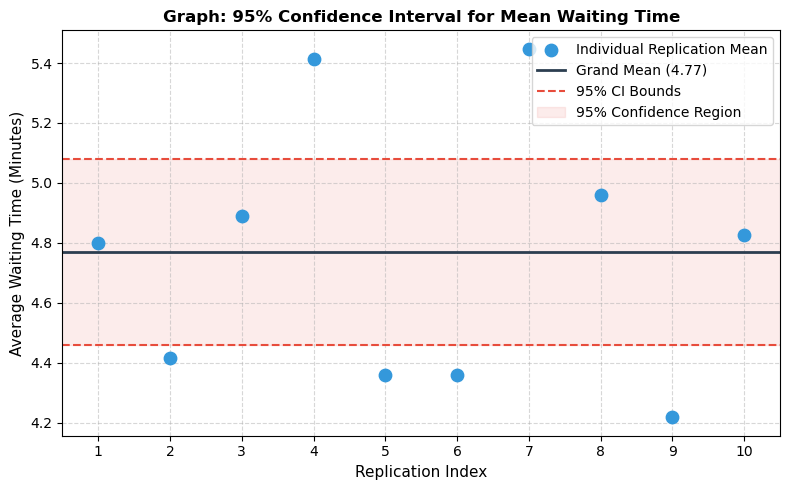

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# --- ১. সিমুলেশন রেপ্লিকেশন ডেটা জেনারেট করা ---
# ধরা যাক আমরা ১০টি স্বাধীন রেপ্লিকেশন রান করে প্রতিবারের গড় ওয়েটিং টাইম (মিনিটে) এগুলো পেয়েছি:
np.random.seed(42)
replications = 10
# বাস্তবসম্মত ওয়েটিং টাইম ডাটা তৈরি (গড় প্রায় ৪.৫ মিনিট)
avg_waiting_times = np.random.normal(loc=4.5, scale=0.6, size=replications)

# --- ২. গাণিতিক ক্যালকুলেশন (Confidence Interval) ---
n = len(avg_waiting_times)
mean = np.mean(avg_waiting_times)
std_err = stats.sem(avg_waiting_times) # Standard Error = S / sqrt(n)

# ৯৫% কনফিডেন্সের জন্য t-value এবং Confidence Interval বের করা
confidence = 0.95
h = std_err * stats.t.ppf((1 + confidence) / 2., n - 1) # Margin of Error

lower_bound = mean - h
upper_bound = mean + h

# --- ৩. টেক্সট রিপোর্ট প্রিন্ট ---
print("=" * 60)
print("          CONFIDENCE INTERVAL ESTIMATION REPORT (95%)")
print("=" * 60)
print(f"Number of Replications (n) : {n}")
print("-" * 60)
for i in range(n):
    print(f"Replication {i+1:2d} Average Waiting Time : {avg_waiting_times[i]:.4f} min")
print("-" * 60)
print(f"Sample Mean (Y-bar)        : {mean:.4f} min")
print(f"Margin of Error (Half-Width): {h:.4f} min")
print(f"95% Confidence Interval    : [{lower_bound:.4f} to {upper_bound:.4f}] min")
print("=" * 60)

# --- ৪. গ্রাফ প্রদর্শন (CI Error Bar Plot) ---
plt.figure(figsize=(8, 5))

# প্রতিটি রেপ্লিকেশনের পয়েন্ট প্লট
plt.scatter(range(1, n+1), avg_waiting_times, color='#3498db', s=80, zorder=3, label='Individual Replication Mean')
# গ্র্যান্ড মিন বা গড় লাইন
plt.axhline(mean, color='#2c3e50', linestyle='-', linewidth=2, label=f'Grand Mean ({mean:.2f})')
# আপার এবং লোয়ার বাউন্ড লাইন
plt.axhline(lower_bound, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'95% CI Bounds')
plt.axhline(upper_bound, color='#e74c3c', linestyle='--', linewidth=1.5)

# কনফিডেন্স ইন্টারভালের ভেতরের অংশ কালার করা
plt.fill_between(range(0, n+2), lower_bound, upper_bound, color='#e74c3c', alpha=0.1, label='95% Confidence Region')

plt.title("Graph: 95% Confidence Interval for Mean Waiting Time", fontsize=12, fontweight='bold')
plt.xlabel("Replication Index", fontsize=11)
plt.ylabel("Average Waiting Time (Minutes)", fontsize=11)
plt.xlim(0.5, n + 0.5)
plt.xticks(range(1, n+1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()